In [1]:
import os
os.chdir('../')

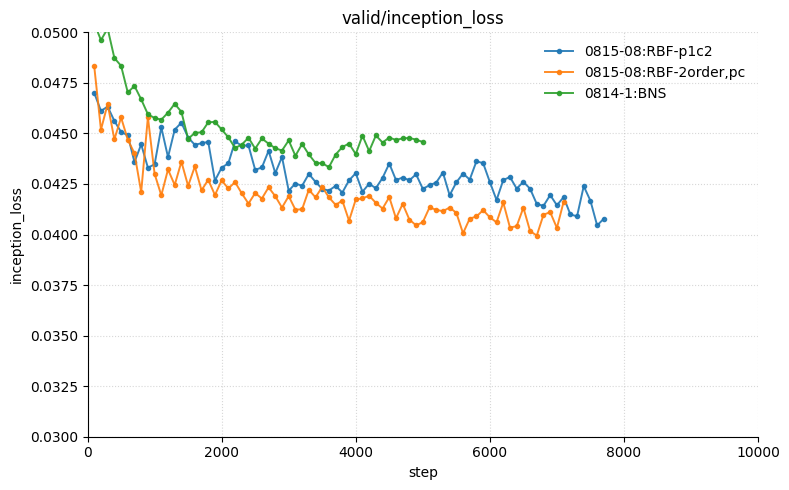

In [22]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/CFG4.0/0815-08:RBF-p1c2",
            "logs/CFG4.0/0815-08:RBF-2order,pc",
            "logs/CFG4.0/0814-1:BNS"]  # ← 개별 러닝 디렉토리들
# TAGS = ['train/inception_loss']
TAGS = ['valid/inception_loss']  # ← 비우면 그림 그리지 않고 가능한 태그만 출력

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r).name)
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.ylim([0.03, 0.05]); plt.xlim([0, 10000]); plt.tight_layout(); plt.show()


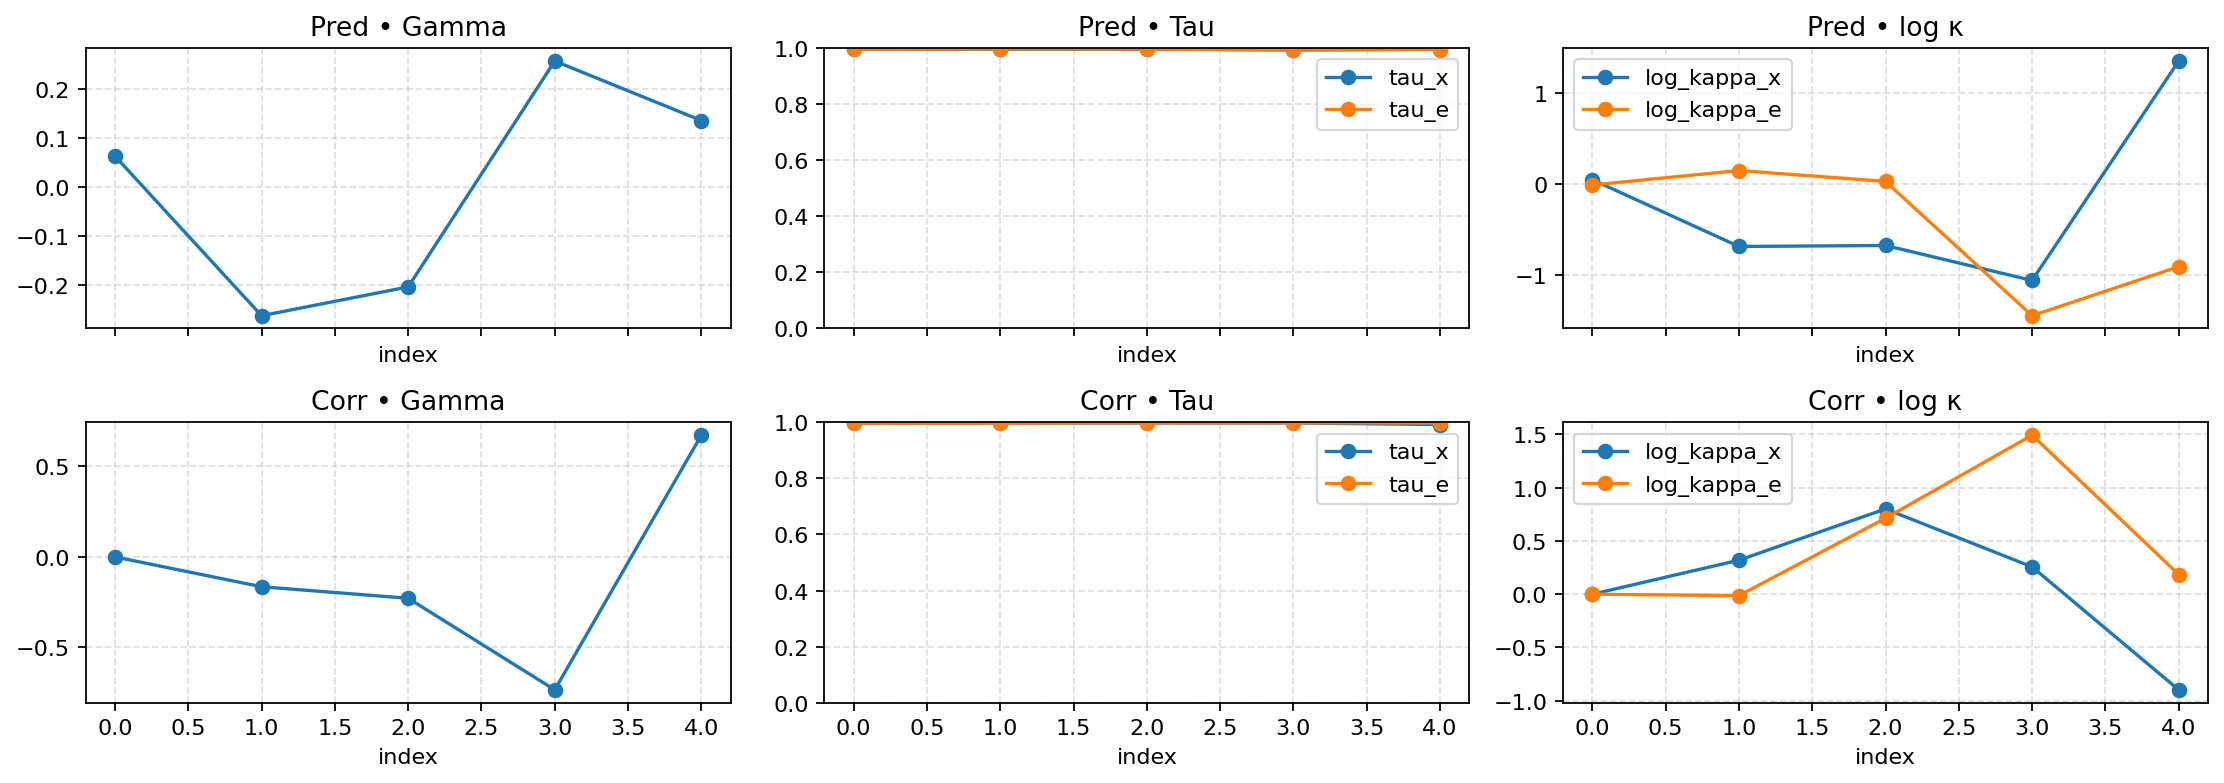

In [57]:
import torch, matplotlib.pyplot as plt

PATH = "logs/CFG4.0/0815-08:RBF-2order,pc/step_00007100.pt"
tau_off, gmax, kmax = 6, 2, 2

# 필요시 corr은 [:,1] 등으로 조정
P_pred = torch.load(PATH, map_location="cpu")["solver_state_dict"]["param_extractor.table"][:,0]
P_corr = torch.load(PATH, map_location="cpu")["solver_state_dict"]["param_extractor.table"][:,1]

def prep(P):
    g, tx, te, kx, ke = [P[:,i] for i in range(5)]
    return (torch.tanh(g)*gmax,
            torch.sigmoid(tx+tau_off), torch.sigmoid(te+tau_off),
            torch.tanh(kx)*kmax, torch.tanh(ke)*kmax)

G1, TX1, TE1, KX1, KE1 = prep(P_pred)
G2, TX2, TE2, KX2, KE2 = prep(P_corr)
x = range(len(G1))

fig, ax = plt.subplots(2, 3, figsize=(14,5), dpi=160, sharex='col')
for r,(G,TX,TE,KX,KE,tag) in enumerate([(G1,TX1,TE1,KX1,KE1,"Pred"),
                                        (G2,TX2,TE2,KX2,KE2,"Corr")]):
    a = ax[r]
    a[0].plot(x, G,  marker='o');                       a[0].set_title(f"{tag} • Gamma"); a[0].grid(True, ls='--', alpha=.4)
    a[1].plot(x, TX, marker='o', label='tau_x')
    a[1].plot(x, TE, marker='o', label='tau_e');        a[1].set_title(f"{tag} • Tau");   a[1].set_ylim(0,1); a[1].legend(); a[1].grid(True, ls='--', alpha=.4)
    a[2].plot(x, KX, marker='o', label='log_kappa_x')
    a[2].plot(x, KE, marker='o', label='log_kappa_e');  a[2].set_title(f"{tag} • log κ"); a[2].legend(); a[2].grid(True, ls='--', alpha=.4)
    for i in range(3): a[i].set_xlabel("index")

fig.tight_layout(); fig.savefig("params_pred_corr.png", dpi=160); plt.show()


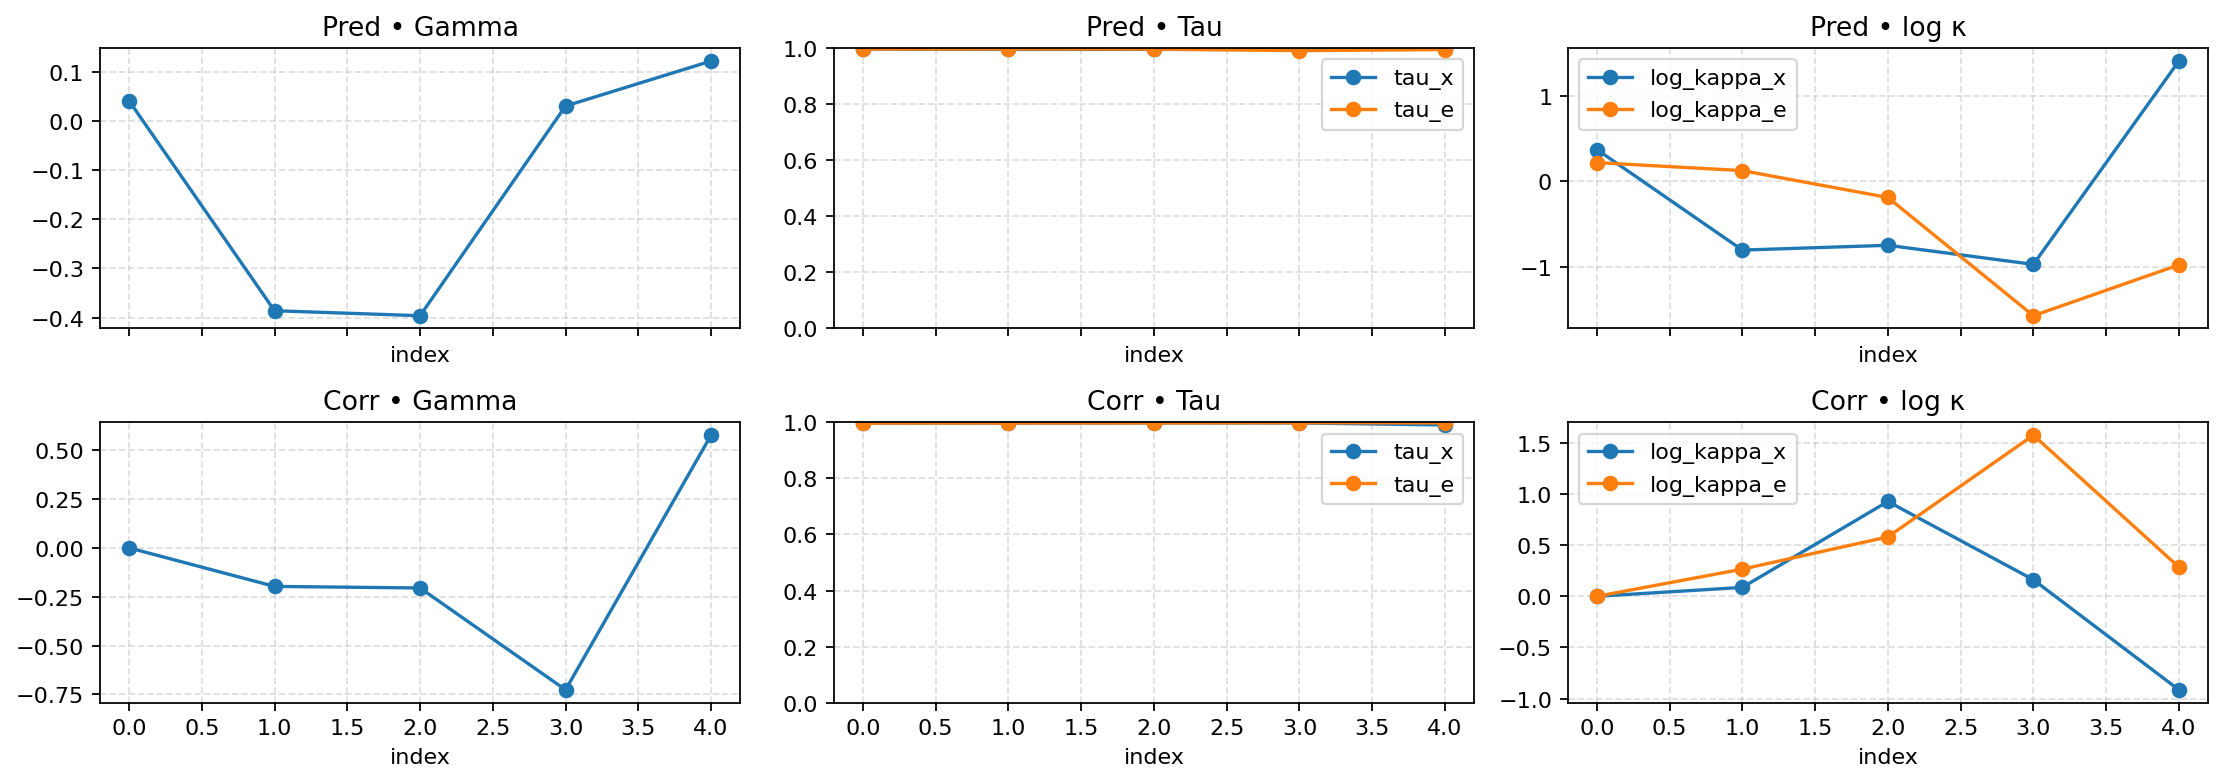

In [59]:
import torch, matplotlib.pyplot as plt

PATH = "logs/CFG4.0/0815-08:RBF-p1c2/step_00007100.pt"
tau_off, gmax, kmax = 6, 2, 2

# 필요시 corr은 [:,1] 등으로 조정
P_pred = torch.load(PATH, map_location="cpu")["solver_state_dict"]["param_extractor.table"][:,0]
P_corr = torch.load(PATH, map_location="cpu")["solver_state_dict"]["param_extractor.table"][:,1]

def prep(P):
    g, tx, te, kx, ke = [P[:,i] for i in range(5)]
    return (torch.tanh(g)*gmax,
            torch.sigmoid(tx+tau_off), torch.sigmoid(te+tau_off),
            torch.tanh(kx)*kmax, torch.tanh(ke)*kmax)

G1, TX1, TE1, KX1, KE1 = prep(P_pred)
G2, TX2, TE2, KX2, KE2 = prep(P_corr)
x = range(len(G1))

fig, ax = plt.subplots(2, 3, figsize=(14,5), dpi=160, sharex='col')
for r,(G,TX,TE,KX,KE,tag) in enumerate([(G1,TX1,TE1,KX1,KE1,"Pred"),
                                        (G2,TX2,TE2,KX2,KE2,"Corr")]):
    a = ax[r]
    a[0].plot(x, G,  marker='o');                       a[0].set_title(f"{tag} • Gamma"); a[0].grid(True, ls='--', alpha=.4)
    a[1].plot(x, TX, marker='o', label='tau_x')
    a[1].plot(x, TE, marker='o', label='tau_e');        a[1].set_title(f"{tag} • Tau");   a[1].set_ylim(0,1); a[1].legend(); a[1].grid(True, ls='--', alpha=.4)
    a[2].plot(x, KX, marker='o', label='log_kappa_x')
    a[2].plot(x, KE, marker='o', label='log_kappa_e');  a[2].set_title(f"{tag} • log κ"); a[2].legend(); a[2].grid(True, ls='--', alpha=.4)
    for i in range(3): a[i].set_xlabel("index")

fig.tight_layout(); fig.savefig("params_pred_corr.png", dpi=160); plt.show()
